In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


--- dp110 数据概览 ---
入口条件: C_in=7.26e-07, V_in=1.48, Area=38.5
沿程最大浓度: 7.26e-07
沿程最小浓度: 2.68e-07
出口(1100m)浓度: 7.26e-07


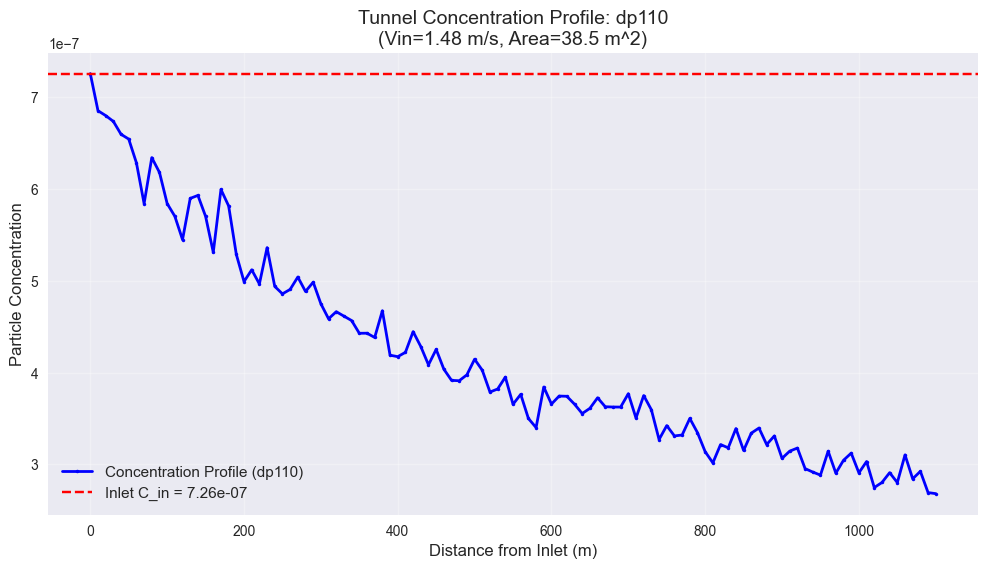

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 0. 绘图环境设置 (Plotting Setup)
# ==========================================
# 使用 Seaborn 默认风格，使图表更美观
plt.style.use('seaborn-v0_8') 
# 中文支持配置 (如果系统中安装了 SimHei 字体可取消注释)
# plt.rcParams['font.sans-serif'] = ['SimHei'] 
# plt.rcParams['axes.unicode_minus'] = False

def plot_case_profile(case_name, cases_file='data/cases.csv', summary_file='data/summary_0_499.csv'):
    """
    读取并绘制指定 Case 的沿程浓度分布曲线 (Concentration Profile).
    用于快速检查原始数据的质量和物理规律是否符合预期。
    
    参数:
        case_name (str): 目标 Case ID (例如 'dp110')
        cases_file (str): 工况参数文件路径 (包含 V_in, C_in, Area)
        summary_file (str): 浓度分布数据文件路径 (包含沿程浓度)
    """
    try:
        # 1. 读取数据 (Data Loading)
        if not os.path.exists(cases_file) or not os.path.exists(summary_file):
            print(f"错误: 找不到数据文件 {cases_file} 或 {summary_file}")
            return

        df_cases = pd.read_csv(cases_file)
        df_summary = pd.read_csv(summary_file)
        
        # 2. 检查 Case 是否存在
        if case_name not in df_cases['Case'].values:
            print(f"错误: 找不到 Case '{case_name}'")
            return
            
        # 3. 提取工况基本信息 (Extract Input Conditions)
        # 获取该 Case 对应的入口浓度(C_in), 风速(V_in), 面积(Area)
        case_info = df_cases[df_cases['Case'] == case_name].iloc[0]
        c_in = case_info['C_in']
        v_in = case_info['V_in']
        area = case_info['Area']
        
        # 4. 提取浓度曲线数据 (Extract Output Profile)
        # 在 summary 表中找到对应那一行
        # drop(columns=['Case']) 去掉非数值列，剩余的列名即为距离点 ('0', '10', ...)
        profile_row = df_summary[df_summary['Case'] == case_name].drop(columns=['Case']).iloc[0]
        
        # 准备绘图数据
        # 将列名转换浮点数作为 X 轴 (Distance)
        distances = [float(col) for col in profile_row.index]
        # 将行数值转换为浮点数作为 Y 轴 (Concentration)
        concentrations = profile_row.values.astype(float)
        
        # 5. 绘图 (Plotting)
        plt.figure(figsize=(12, 6))
        
        # 绘制沿程浓度曲线 (蓝色实线)
        plt.plot(distances, concentrations, label=f'Concentration Profile ({case_name})', 
                 color='blue', linewidth=2, marker='.', markersize=5)
        
        # 绘制入口浓度参考线 (红色虚线)
        # 用于直观对比当前浓度相对于入口浓度的衰减情况
        plt.axhline(y=c_in, color='red', linestyle='--', label=f'Inlet C_in = {c_in:.2e}')
        
        # 图表装饰 (Labels & Title)
        plt.title(f"Tunnel Concentration Profile: {case_name}\n"
                  f"(Vin={v_in:.2f} m/s, Area={area:.1f} m^2)", fontsize=14)
        plt.xlabel("Distance from Inlet (m)", fontsize=12)
        plt.ylabel("Particle Concentration (kg/m^3)", fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3) # 添加网格以便读数
        
        # 6. 打印统计信息 (Statistics)
        print(f"--- {case_name} 数据概览 ---")
        print(f"入口条件: C_in={c_in:.2e}, V_in={v_in:.2f}, Area={area:.1f}")
        print(f"沿程最大浓度: {concentrations.max():.2e}")
        print(f"沿程最小浓度: {concentrations.min():.2e}")
        print(f"出口(1100m)浓度: {concentrations[-1]:.2e}")
        
        plt.show()
        
    except Exception as e:
        print(f"发生错误: {e}")

# ==========================================
# 6. 执行绘图
# ==========================================
# 在此处修改你想查看的 Case 名字 (例如 'dp0', 'dp1', 'dp110')
target_case = 'dp110' 
plot_case_profile(target_case)